In [31]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import requests
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
import lightgbm as lgb
import xgboost as xgb

# Paths
RAW_DATA_DIR = Path("data/01_raw_c")
PROCESSED_DATA_DIR = Path("data/02_processed")
FEATURES_DATA_DIR = Path("data/03_features")
CLEAN_DATA_FILE = PROCESSED_DATA_DIR / "clean_cve_data.csv"

# Ensure directories exist
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_DATA_DIR.mkdir(parents=True, exist_ok=True)
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete. Paths and libraries ready.")


Setup complete. Paths and libraries ready.


In [32]:
YEARS_TO_FETCH = list(range(1999, 2026))
BASE_URL = "https://raw.githubusercontent.com/espressif/esp-nvd-mirror/master/cve"

def get_cves_per_year(year):
    if year >= 2021:
        return 1500
    elif year >= 2010:
        return 500
    else:
        return 100

def download_cve(cve_id, year_dir):
    file_path = year_dir / cve_id
    if file_path.exists():
        return
    url = f"{BASE_URL}/{year_dir.name}/{cve_id}"
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            file_path.write_bytes(r.content)
    except:
        pass

def parse_cve_json(file_path):
    import json
    with open(file_path, "r", encoding="utf-8") as f:
        j = json.load(f)
    cve_id = j['cve']['id']
    desc = j['cve']['descriptions'][0]['value'] if j['cve'].get('descriptions') else ''
    cwe = j['cve']['weaknesses'][0]['description'][0]['value'] if j['cve'].get('weaknesses') else 'UNKNOWN'
    severity = j['cve']['metrics']['cvssMetricV2'][0]['baseSeverity'] if j['cve'].get('metrics') else 'UNKNOWN'
    return {'CVE_ID': cve_id, 'Description': desc, 'CWE': cwe, 'Severity': severity.upper()}


In [33]:
def load_and_clean_raw():
    """Parse all JSONs from folders 1999-2025 and save a clean CSV."""
    all_rows = []
    for year in YEARS_TO_FETCH:
        year_dir = RAW_DATA_DIR / str(year)
        if not year_dir.exists():
            continue
        for f in year_dir.glob("CVE-*.json"):
            try:
                all_rows.append(parse_cve_json(f))
            except:
                continue
    df = pd.DataFrame(all_rows)
    df = df.dropna(subset=['Description', 'CWE', 'Severity'])
    df.reset_index(drop=True, inplace=True)
    df.to_csv(CLEAN_DATA_FILE, index=False)
    return df

df = load_and_clean_raw()
print(f"Clean data ready: {df.shape[0]} rows, {df.shape[1]} columns")


Clean data ready: 9654 rows, 4 columns


In [34]:
# ========== Block 4: Feature Engineering ==========
# Novel features: description length, keyword counts, CVSS numeric parsing
def add_novel_features(df):
    df["desc_length"] = df["Description"].str.len()
    keywords = ["overflow", "remote", "denial", "execute", "injection"]
    for kw in keywords:
        df[f"kw_{kw}"] = df["Description"].str.lower().str.contains(kw).astype(int)
    return df

df = add_novel_features(df)

# SBERT embeddings
sbert_model = SentenceTransformer(SBERT_MODEL_NAME)
text_embeddings = sbert_model.encode(df["Description"].tolist(), batch_size=64, show_progress_bar=True)

# Combine embeddings + numeric + categorical
X_df = pd.concat([
    pd.DataFrame(text_embeddings),
    df[["CWE", "desc_length"] + [f"kw_{kw}" for kw in ["overflow","remote","denial","execute","injection"]]].reset_index(drop=True)
], axis=1)
X_df.columns = X_df.columns.astype(str)
y = df["Severity"]
print(f"Features shape: {X_df.shape}, Target shape: {y.shape}")


c:\Python311\Lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Batches: 100%|██████████| 151/151 [00:08<00:00, 17.33it/s]


Features shape: (9654, 391), Target shape: (9654,)


In [37]:
# ========== Block 5: Train-Test Split & Pipeline ==========
X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.2, random_state=42, stratify=y)

numeric_features = [col for col in X_df.columns if col not in ["CWE"]]
categorical_features = ["CWE"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

base_estimators = [
    ("lgbm", lgb.LGBMClassifier(device="gpu", random_state=42)),
    ("xgb", xgb.XGBClassifier(tree_method="hist", device="cuda", random_state=42, eval_metric="mlogloss"))
]
meta_classifier = LogisticRegression(max_iter=1000)

stacking_classifier = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_classifier,
    cv=5
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", stacking_classifier)
])

print("Training stacking classifier on GPU...")
pipeline.fit(X_train, y_train)
print("Model training complete!")

# Save pipeline
# Save pipeline
PIPELINE_FILE = FEATURES_DATA_DIR / "stacking_pipeline.pkl"

joblib.dump(pipeline, PIPELINE_FILE)
print(f"Pipeline saved: {PIPELINE_FILE}")


Training stacking classifier on GPU...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 98284
[LightGBM] [Info] Number of data points in the train set: 7723, number of used features: 437
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 387 dense feature groups (2.86 MB) transferred to GPU in 0.007172 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -1.149340
[LightGBM] [Info] Start training from score -1.907053
[LightGBM] [Info] Start training from score -0.703167
[LightGBM] [Info] Start training from score -3.228373
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 98274
[LightGBM] [Info] Number of data points in the train set: 6178, number of used features: 432
[LightGBM] [Info] Using GPU Devic

c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 98272
[LightGBM] [Info] Number of data points in the train set: 6178, number of used features: 431
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 387 dense feature groups (2.29 MB) transferred to GPU in 0.006547 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -1.149071
[LightGBM] [Info] Start training from score -1.907642
[LightGBM] [Info] Start training from score -0.703233
[LightGBM] [Info] Start training from score -3.227492


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 98270
[LightGBM] [Info] Number of data points in the train set: 6178, number of used features: 430
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 387 dense feature groups (2.29 MB) transferred to GPU in 0.008436 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -1.149071
[LightGBM] [Info] Start training from score -1.907642
[LightGBM] [Info] Start training from score -0.703233
[LightGBM] [Info] Start training from score -3.227492


...

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 98270
[LightGBM] [Info] Number of data points in the train set: 6179, number of used features: 430
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 387 dense feature groups (2.29 MB) transferred to GPU in 0.007888 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -1.149744
[LightGBM] [Info] Start training from score -1.906714
[LightGBM] [Info] Start training from score -0.703068
[LightGBM] [Info] Start training from score -3.227654


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 98270
[LightGBM] [Info] Number of data points in the train set: 6179, number of used features: 430
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 387 dense feature groups (2.29 MB) transferred to GPU in 0.008861 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -1.149744
[LightGBM] [Info] Start training from score -1.906714
[LightGBM] [Info] Start training from score -0.703068
[LightGBM] [Info] Start training from score -3.227654


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Model training complete!
Pipeline saved: data\03_features\stacking_pipeline.pkl


In [41]:
def predict_severity(description, cwe="UNKNOWN"):
    """
    Predict CVE severity and risk score from description.
    """
    # 1️⃣ Generate SBERT embeddings
    emb = sbert_model.encode([description])
    df_numeric = pd.DataFrame(emb)
    
    # 2️⃣ Add additional numeric/categorical features
    novel_features = {
        "CWE": [cwe],
        "desc_length": [len(description)],
    }
    for kw in ["overflow","remote","denial","execute","injection"]:
        novel_features[f"kw_{kw}"] = [int(kw in description.lower())]
    df_novel = pd.DataFrame(novel_features)
    
    # 3️⃣ Combine embeddings + novel features
    df_pred = pd.concat([df_numeric, df_novel], axis=1)
    
    # ✅ Convert all column names to strings
    df_pred.columns = df_pred.columns.astype(str)
    
    # 4️⃣ Predict using pipeline
    pred_label = pipeline.predict(df_pred)[0]
    pred_prob = pipeline.predict_proba(df_pred).max()
    
    # 5️⃣ Map probability to risk level
    if pred_prob >= 0.8:
        risk_level = "CRITICAL"
    elif pred_prob >= 0.6:
        risk_level = "HIGH"
    elif pred_prob >= 0.4:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"
    
    return pred_label, pred_prob, risk_level

desc = "A remote code execution vulnerability allows attackers to execute arbitrary code."
pred_label, pred_prob, risk_level = predict_severity(desc, "NVD-CWE-Other")
print(f"Predicted Severity: {pred_label}")
print(f"Risk Score: {pred_prob:.2f}")
print(f"Risk Level: {risk_level}")


Predicted Severity: HIGH
Risk Score: 0.93
Risk Level: CRITICAL


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [42]:
def fetch_latest_cves(latest_year=None):
    """Fetch CVEs for latest year and merge into clean CSV."""
    if latest_year is None:
        latest_year = datetime.now().year
    year_dir = RAW_DATA_DIR / str(latest_year)
    year_dir.mkdir(exist_ok=True)

    CVES_PER_YEAR_LIMIT = get_cves_per_year(latest_year)
    cve_ids = [f"CVE-{latest_year}-{num:04d}.json" for num in range(1, CVES_PER_YEAR_LIMIT + 1)]

    with ThreadPoolExecutor(max_workers=20) as executor:
        list(tqdm(executor.map(lambda cve: download_cve(cve, year_dir), cve_ids),
                  total=len(cve_ids),
                  desc=f"Fetching latest CVEs for {latest_year}"))

    # Parse newly downloaded CVEs
    new_rows = []
    for f in year_dir.glob("CVE-*.json"):
        try:
            new_rows.append(parse_cve_json(f))
        except:
            continue
    df_new = pd.DataFrame(new_rows)
    df_new.dropna(subset=["Description", "CWE", "Severity"], inplace=True)

    # Merge with old data
    df_old = pd.read_csv(CLEAN_DATA_FILE)
    df_combined = pd.concat([df_old, df_new]).drop_duplicates(subset="CVE_ID").reset_index(drop=True)
    df_combined.to_csv(CLEAN_DATA_FILE, index=False)
    print(f"Updated clean CVE dataset: {df_combined.shape[0]} rows")
    return df_combined

# Run this to always update the dataset before features
df = fetch_latest_cves()


Fetching latest CVEs for 2025: 100%|██████████| 1500/1500 [00:16<00:00, 88.81it/s] 


Updated clean CVE dataset: 9654 rows


In [43]:
# Example: SBERT embeddings
from sentence_transformers import SentenceTransformer
SBERT_MODEL_NAME = "all-MiniLM-L6-v2"
sbert_model = SentenceTransformer(SBERT_MODEL_NAME)
text_embeddings = sbert_model.encode(df['Description'].tolist(), show_progress_bar=True)

# Combine embeddings with CWE
X_df = pd.concat([
    pd.DataFrame(text_embeddings),
    df[['CWE']].reset_index(drop=True)
], axis=1)

# Target
y = df['Severity']

# Ensure column names are strings
X_df.columns = X_df.columns.astype(str)
print("Feature matrix shape:", X_df.shape)


c:\Python311\Lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Batches: 100%|██████████| 302/302 [00:10<00:00, 28.46it/s]


Feature matrix shape: (9654, 385)


In [44]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessor
numeric_features = [col for col in X_df.columns if col != 'CWE']
categorical_features = ['CWE']
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# Base estimators
base_estimators = [
    ('lgbm', lgb.LGBMClassifier(device='gpu', random_state=42)),
    ('xgb', xgb.XGBClassifier(tree_method='gpu_hist', device='cuda', random_state=42, eval_metric='mlogloss'))
]
meta_classifier = LogisticRegression(max_iter=1000)

stacking_classifier = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_classifier,
    cv=5
)

# Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', stacking_classifier)
])

print("Training stacking classifier on GPU...")
pipeline.fit(X_train, y_train)
print("Model training complete.")

# Save
joblib.dump(pipeline, FEATURES_DATA_DIR / "stacking_pipeline.pkl")


Training stacking classifier on GPU...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 98014
[LightGBM] [Info] Number of data points in the train set: 7723, number of used features: 431
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 385 dense feature groups (2.86 MB) transferred to GPU in 0.010194 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -1.149340
[LightGBM] [Info] Start training from score -1.907053
[LightGBM] [Info] Start training from score -0.703167
[LightGBM] [Info] Start training from score -3.228373


C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning: [12:24:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 98004
[LightGBM] [Info] Number of data points in the train set: 6178, number of used features: 426
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 385 dense feature groups (2.29 MB) transferred to GPU in 0.008120 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -1.149071
[LightGBM] [Info] Start training from score -1.906552
[LightGBM] [Info] Start training from score -0.703233
[LightGBM] [Info] Start training from score -3.231582


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 98002
[LightGBM] [Info] Number of data points in the train set: 6178, number of used features: 425
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 385 dense feature groups (2.29 MB) transferred to GPU in 0.008151 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -1.149071
[LightGBM] [Info] Start training from score -1.907642
[LightGBM] [Info] Start training from score -0.703233
[LightGBM] [Info] Start training from score -3.227492


...

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 98000
[LightGBM] [Info] Number of data points in the train set: 6179, number of used features: 424
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 385 dense feature groups (2.29 MB) transferred to GPU in 0.008384 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -1.149744
[LightGBM] [Info] Start training from score -1.906714
[LightGBM] [Info] Start training from score -0.703068
[LightGBM] [Info] Start training from score -3.227654


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning: [12:24:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:2676: UserWarning: [12:24:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[

Model training complete.


C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:2676: UserWarning: [12:25:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:
c:\Python311\Lib\pickle.py:578: UserWarning: [12:25:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  rv = reduce(self.proto)


['data\\03_features\\stacking_pipeline.pkl']

In [45]:
# Load trained pipeline
pipeline = joblib.load(FEATURES_DATA_DIR / "stacking_pipeline.pkl")

# Define a risk scoring function
def risk_score(severity):
    """Convert severity class to a numeric risk score (example)."""
    mapping = {
        "CRITICAL": 5,
        "HIGH": 4,
        "MEDIUM": 3,
        "LOW": 2,
        "UNKNOWN": 1
    }
    return mapping.get(severity.upper(), 0)

# Prediction function
def predict_cve_risk(description, cwe='UNKNOWN'):
    """
    Takes CVE description and CWE, outputs predicted severity and risk score.
    """
    # Compute SBERT embedding
    emb = sbert_model.encode([description])
    
    # Combine embedding with CWE
    X_input = pd.DataFrame(emb)
    X_input['CWE'] = cwe
    
    # Ensure columns match training
    X_input.columns = X_df.columns
    
    # Predict
    pred_severity = pipeline.predict(X_input)[0]
    pred_proba = pipeline.predict_proba(X_input)
    
    # Risk score
    score = risk_score(pred_severity)
    
    # Return results
    return {
        "Predicted_Severity": pred_severity,
        "Risk_Score": score,
        "Probabilities": dict(zip(pipeline.classes_, pred_proba[0]))
    }

# Example usage
example_desc = "Remote code execution vulnerability in XYZ server allows attackers to execute arbitrary commands."
example_cwe = "CWE-94"
result = predict_cve_risk(example_desc, example_cwe)
print(result)


{'Predicted_Severity': 'HIGH', 'Risk_Score': 4, 'Probabilities': {'HIGH': 0.9310882227611329, 'LOW': 0.0043995543743240995, 'MEDIUM': 0.0641936077160594, 'UNKNOWN': 0.0003186151484836282}}


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:2676: UserWarning: [12:25:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:
c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [46]:
import json
from datetime import datetime

# Configuration
RAW_DATA_DIR = Path("data/01_raw_c")
LATEST_YEAR = datetime.now().year

def fetch_new_cves(year=LATEST_YEAR):
    """Download new CVEs for the current year if not already present."""
    year_dir = RAW_DATA_DIR / str(year)
    year_dir.mkdir(exist_ok=True)
    
    CVES_PER_YEAR_LIMIT = 1500  # adjust as needed
    cve_ids = [f"CVE-{year}-{num:04d}.json" for num in range(1, CVES_PER_YEAR_LIMIT + 1)]
    
    for cve_id in cve_ids:
        file_path = year_dir / cve_id
        if not file_path.exists():
            url = f"https://raw.githubusercontent.com/espressif/esp-nvd-mirror/master/cve/{year}/{cve_id}"
            try:
                response = requests.get(url, timeout=10)
                if response.status_code == 200:
                    with open(file_path, "wb") as f:
                        f.write(response.content)
            except requests.exceptions.RequestException as e:
                print(f"Error fetching {cve_id}: {e}")

def parse_new_cves(year=LATEST_YEAR):
    """Parse new JSON CVEs and convert to DataFrame."""
    year_dir = RAW_DATA_DIR / str(year)
    data = []
    for json_file in year_dir.glob("CVE-*.json"):
        with open(json_file, "r", encoding="utf-8") as f:
            cve = json.load(f).get("cve", {})
            desc = ""
            if cve.get("descriptions"):
                for d in cve["descriptions"]:
                    if d.get("lang") == "en":
                        desc = d.get("value", "")
                        break
            cwe = "UNKNOWN"
            if cve.get("weaknesses"):
                cwe_list = cve["weaknesses"]
                if cwe_list and cwe_list[0].get("description"):
                    cwe = cwe_list[0]["description"][0]["value"]
            severity = "UNKNOWN"
            if cve.get("metrics", {}).get("cvssMetricV2"):
                severity = cve["metrics"]["cvssMetricV2"][0].get("baseSeverity", "UNKNOWN").upper()
            data.append({
                "CVE_ID": cve.get("id", ""),
                "Description": desc,
                "CWE": cwe,
                "Severity": severity
            })
    return pd.DataFrame(data)

def update_model():
    """Fetch new CVEs, process, and retrain model incrementally."""
    print("Fetching new CVEs...")
    fetch_new_cves()
    new_df = parse_new_cves()
    
    if new_df.empty:
        print("No new CVEs found.")
        return
    
    # Filter new CVEs not already in training data
    existing_ids = set(X_df.index)  # assuming X_df is your existing training DF
    new_df = new_df[~new_df["CVE_ID"].isin(existing_ids)]
    
    if new_df.empty:
        print("All CVEs are already in dataset.")
        return
    
    print(f"{len(new_df)} new CVEs found. Updating features and retraining...")
    
    # SBERT embeddings for new CVEs
    new_embeddings = sbert_model.encode(new_df["Description"].tolist())
    
    # Combine embeddings with CWE
    X_new = pd.DataFrame(new_embeddings)
    X_new['CWE'] = new_df['CWE'].astype(str).values
    X_new.columns = X_df.columns  # ensure column match
    y_new = new_df["Severity"]
    
    # Combine with old training data
    X_combined = pd.concat([X_df, X_new], ignore_index=True)
    y_combined = pd.concat([y, y_new], ignore_index=True)
    
    # Retrain pipeline
    print("Retraining stacking classifier with updated data...")
    pipeline.fit(X_combined, y_combined)
    
    # Save updated pipeline
    joblib.dump(pipeline, FEATURES_DATA_DIR / "stacking_pipeline.pkl")
    print("Model updated and saved successfully!")

# Example: Run the updater
update_model()


Fetching new CVEs...
1269 new CVEs found. Updating features and retraining...
Retraining stacking classifier with updated data...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 98042
[LightGBM] [Info] Number of data points in the train set: 10923, number of used features: 445
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 385 dense feature groups (4.04 MB) transferred to GPU in 0.010480 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -1.259146
[LightGBM] [Info] Start training from score -2.000181
[LightGBM] [Info] Start training from score -0.775848
[LightGBM] [Info] Start training from score -2.116274


C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning: [12:26:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 98032
[LightGBM] [Info] Number of data points in the train set: 8738, number of used features: 440
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 385 dense feature groups (3.23 MB) transferred to GPU in 0.008186 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -1.259020
[LightGBM] [Info] Start training from score -2.000473
[LightGBM] [Info] Start training from score -0.775902
[LightGBM] [Info] Start training from score -2.116038


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 98034
[LightGBM] [Info] Number of data points in the train set: 8738, number of used features: 441
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 385 dense feature groups (3.23 MB) transferred to GPU in 0.008734 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -1.259020
[LightGBM] [Info] Start training from score -2.000473
[LightGBM] [Info] Start training from score -0.775902
[LightGBM] [Info] Start training from score -2.116038


...

c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 98022
[LightGBM] [Info] Number of data points in the train set: 8739, number of used features: 435
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 385 dense feature groups (3.23 MB) transferred to GPU in 0.007619 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -1.259134
[LightGBM] [Info] Start training from score -1.999742
[LightGBM] [Info] Start training from score -0.775768
[LightGBM] [Info] Start training from score -2.117103


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning: [12:27:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:2676: UserWarning: [12:27:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[

Model updated and saved successfully!


c:\Python311\Lib\pickle.py:578: UserWarning: [12:27:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  rv = reduce(self.proto)


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification Report:
              precision    recall  f1-score   support

        HIGH       0.89      0.95      0.92       612
         LOW       1.00      1.00      1.00       287
      MEDIUM       0.96      0.92      0.94       956
     UNKNOWN       1.00      1.00      1.00        76

    accuracy                           0.94      1931
   macro avg       0.96      0.97      0.96      1931
weighted avg       0.95      0.94      0.94      1931



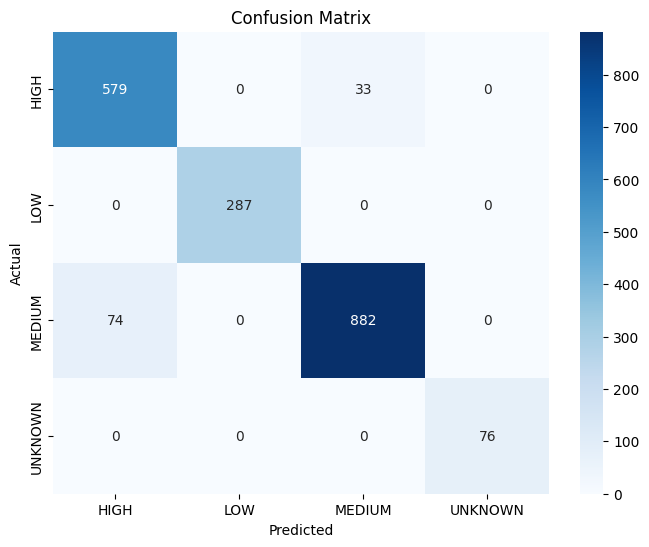

In [47]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Predict on test set
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)

# 2️⃣ Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 3️⃣ Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=pipeline.classes_, yticklabels=pipeline.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification Report:
              precision    recall  f1-score   support

        HIGH       0.89      0.95      0.92       612
         LOW       1.00      1.00      1.00       287
      MEDIUM       0.96      0.92      0.94       956
     UNKNOWN       1.00      1.00      1.00        76

    accuracy                           0.94      1931
   macro avg       0.96      0.97      0.96      1931
weighted avg       0.95      0.94      0.94      1931



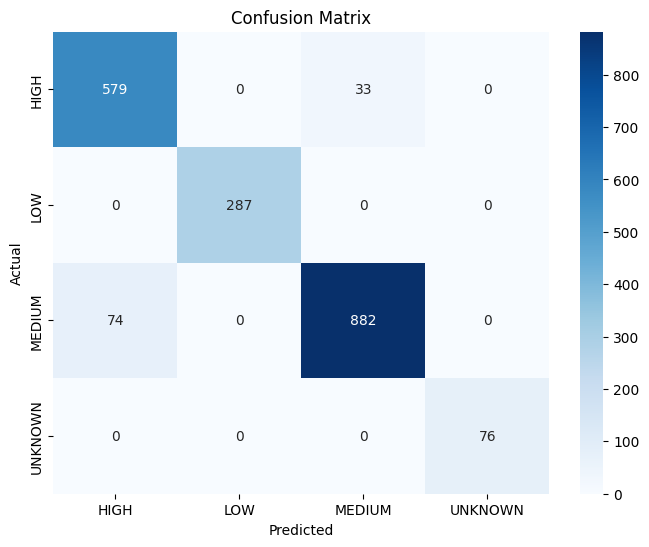

In [48]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Predict on test set
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)

# 2️⃣ Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 3️⃣ Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=pipeline.classes_, yticklabels=pipeline.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


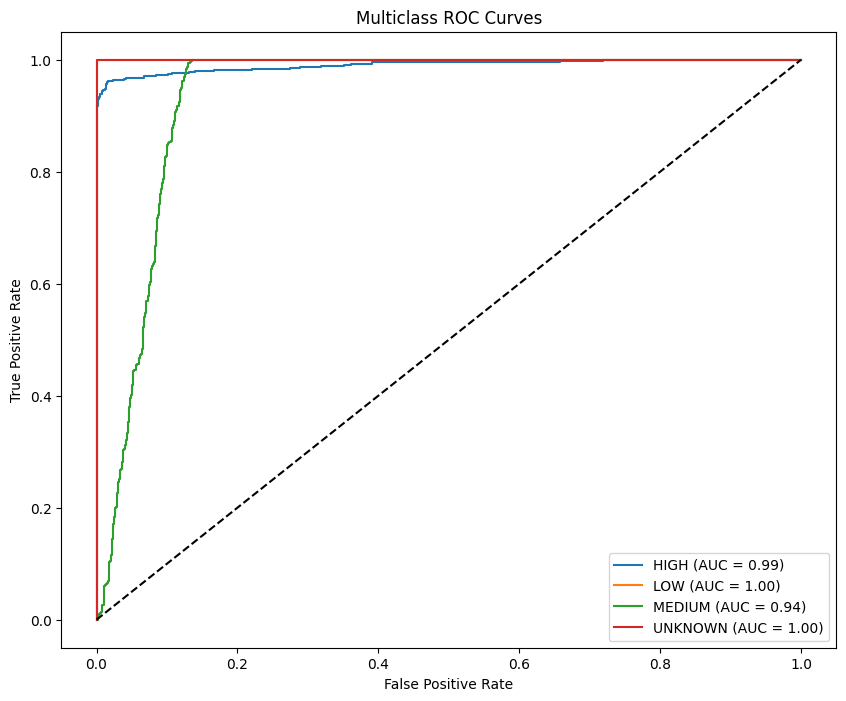

In [49]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import RocCurveDisplay

# Binarize labels for multiclass ROC
y_test_bin = label_binarize(y_test, classes=pipeline.classes_)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10,8))
for i, class_name in enumerate(pipeline.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc_score(y_test_bin[:, i], y_prob[:, i]):.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves")
plt.legend(loc="lower right")
plt.show()


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy on 100 samples: 0.9800
Macro F1 Score on 100 samples: 0.9872

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.94      1.00      0.97        30
         LOW       1.00      1.00      1.00        14
      MEDIUM       1.00      0.96      0.98        54
     UNKNOWN       1.00      1.00      1.00         2

    accuracy                           0.98       100
   macro avg       0.98      0.99      0.99       100
weighted avg       0.98      0.98      0.98       100



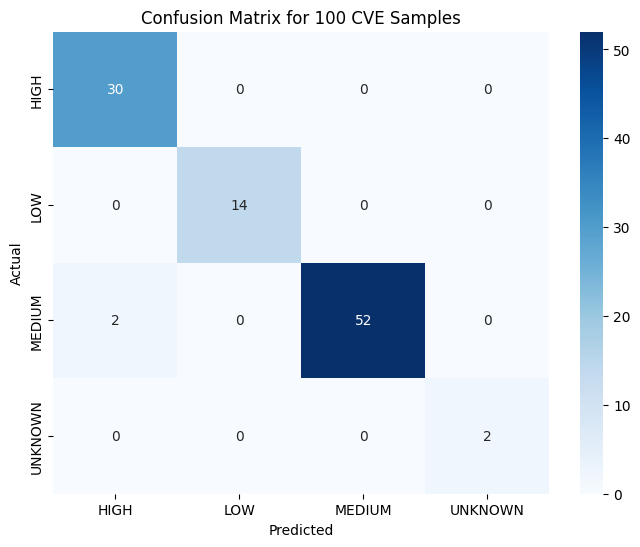

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11180\2276656252.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_counts.index, y=risk_counts.values, palette="Reds_r")


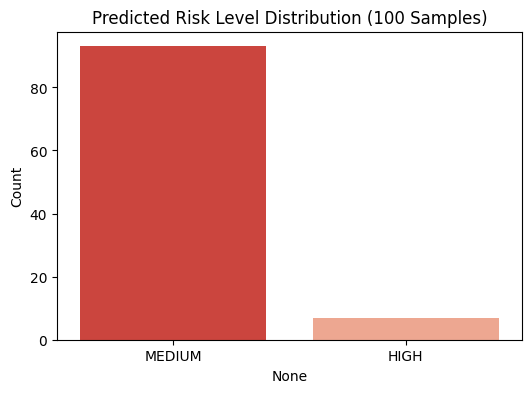

In [50]:
# =========================
# Test 100 CVE samples & Evaluate
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 1️⃣ Sample 100 random test examples
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), size=100, replace=False)
X_sample = X_test.iloc[sample_indices]
y_sample = y_test.iloc[sample_indices]

# 2️⃣ Predict using pipeline
y_pred_sample = pipeline.predict(X_sample)
y_prob_sample = pipeline.predict_proba(X_sample).max(axis=1)  # Max probability per sample

# 3️⃣ Map probabilities to risk levels
def risk_level(prob):
    if prob >= 0.9:
        return "CRITICAL"
    elif prob >= 0.7:
        return "HIGH"
    elif prob >= 0.4:
        return "MEDIUM"
    else:
        return "LOW"

risk_levels = [risk_level(p) for p in y_prob_sample]

# 4️⃣ Metrics
acc_sample = accuracy_score(y_sample, y_pred_sample)
f1_sample = f1_score(y_sample, y_pred_sample, average='macro')

print(f"Accuracy on 100 samples: {acc_sample:.4f}")
print(f"Macro F1 Score on 100 samples: {f1_sample:.4f}")
print("\nClassification Report:")
print(classification_report(y_sample, y_pred_sample))

# 5️⃣ Confusion Matrix
cm_sample = confusion_matrix(y_sample, y_pred_sample)
plt.figure(figsize=(8,6))
sns.heatmap(cm_sample, annot=True, fmt='d', cmap='Blues',
            xticklabels=pipeline.classes_, yticklabels=pipeline.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for 100 CVE Samples")
plt.show()

# 6️⃣ Predicted Risk Level Distribution
risk_counts = pd.Series(risk_levels).value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=risk_counts.index, y=risk_counts.values, palette="Reds_r")
plt.title("Predicted Risk Level Distribution (100 Samples)")
plt.ylabel("Count")
plt.show()


===== MODEL HEALTH CHECK =====


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training Accuracy: 0.9447, F1 Score: 0.9644
Test Accuracy: 0.9446, F1 Score: 0.9646

Classification Report (Test Set):
              precision    recall  f1-score   support

        HIGH       0.89      0.95      0.92       612
         LOW       1.00      1.00      1.00       287
      MEDIUM       0.96      0.92      0.94       956
     UNKNOWN       1.00      1.00      1.00        76

    accuracy                           0.94      1931
   macro avg       0.96      0.97      0.96      1931
weighted avg       0.95      0.94      0.94      1931



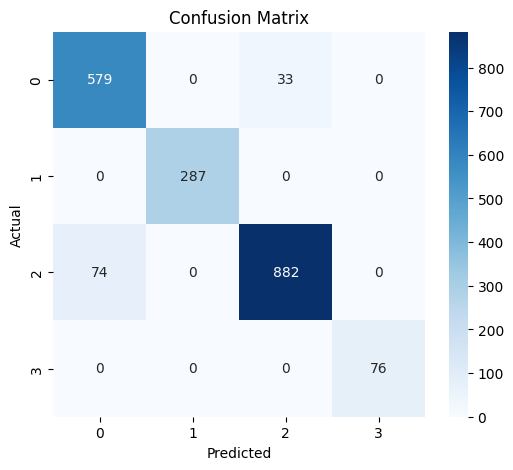

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 97938
[LightGBM] [Info] Number of data points in the train set: 772, number of used features: 393
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 385 dense feature groups (0.29 MB) transferred to GPU in 0.009870 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -0.129837
[LightGBM] [Info] Start training from score -2.459330
[LightGBM] [Info] Start training from score -3.316780
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning: [12:43:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 79122
[LightGBM] [Info] Number of data points in the train set: 617, number of used features: 393
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 385 dense feature groups (0.23 MB) transferred to GPU in 0.009822 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -0.129603
[LightGBM] [Info] Start training from score -2.454577
[LightGBM] [Info] Start training from score -3.333827
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 385 dense feature groups (0.23 MB) transferred to GPU in 0.006580 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -0.129603
[LightGBM] [Info] Start training from score -2.454577
[LightGBM] [Info] Start training from score -3.333827
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

...

c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 97990
[LightGBM] [Info] Number of data points in the train set: 6179, number of used features: 419
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 385 dense feature groups (2.29 MB) transferred to GPU in 0.007179 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -1.149233
[LightGBM] [Info] Start training from score -1.905626
[LightGBM] [Info] Start training from score -0.703068
[LightGBM] [Info] Start training from score -3.235850


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 97984
[LightGBM] [Info] Number of data points in the train set: 6179, number of used features: 416
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 385 dense feature groups (2.29 MB) transferred to GPU in 0.007394 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -1.149744
[LightGBM] [Info] Start training from score -1.905626
[LightGBM] [Info] Start training from score -0.702742
[LightGBM] [Info] Start training from score -3.235850


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning: [13:03:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:2676: UserWarning: [13:03:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[

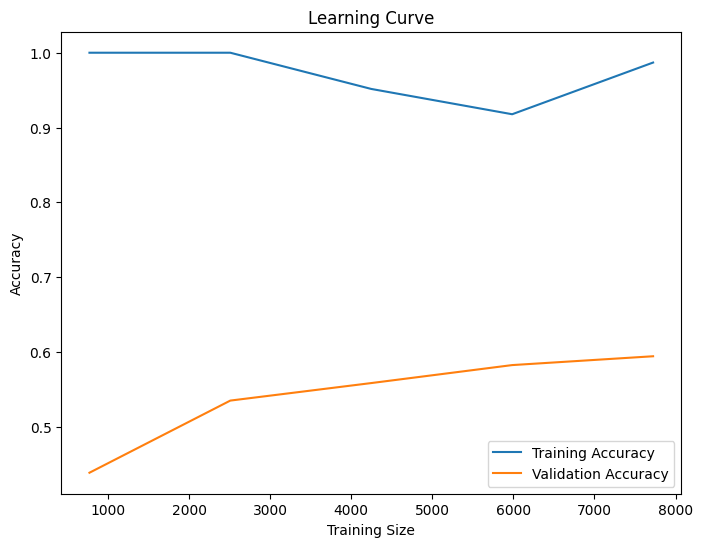

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 98016
[LightGBM] [Info] Number of data points in the train set: 7723, number of used features: 432
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 385 dense feature groups (2.86 MB) transferred to GPU in 0.007172 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -1.149340
[LightGBM] [Info] Start training from score -1.907053
[LightGBM] [Info] Start training from score -0.703167
[LightGBM] [Info] Start training from score -3.228373


C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning: [13:03:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 98008
[LightGBM] [Info] Number of data points in the train set: 6178, number of used features: 428
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 385 dense feature groups (2.29 MB) transferred to GPU in 0.007341 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -1.149582
[LightGBM] [Info] Start training from score -1.906552
[LightGBM] [Info] Start training from score -0.702907
[LightGBM] [Info] Start training from score -3.231582


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 98012
[LightGBM] [Info] Number of data points in the train set: 6178, number of used features: 430
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 385 dense feature groups (2.29 MB) transferred to GPU in 0.007407 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -1.149582
[LightGBM] [Info] Start training from score -1.907642
[LightGBM] [Info] Start training from score -0.702907
[LightGBM] [Info] Start training from score -3.227492


...

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 97984
[LightGBM] [Info] Number of data points in the train set: 6180, number of used features: 416
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 385 dense feature groups (2.29 MB) transferred to GPU in 0.007346 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -1.149906
[LightGBM] [Info] Start training from score -1.905787
[LightGBM] [Info] Start training from score -0.702903
[LightGBM] [Info] Start training from score -3.231905


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning: [13:07:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:2676: UserWarning: [13:07:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[

Cross-Validation Accuracy: 0.5923 ± 0.0249


C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:2676: UserWarning: [13:07:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:
c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:2676: UserWarning: [13:07:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_feat

TypeError: 'LGBMClassifier' object is not subscriptable

In [ ]:
# ======================= MODEL HEALTH CHECK =======================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import learning_curve, cross_val_score

print("===== MODEL HEALTH CHECK =====")

# 1️⃣ Train vs Test Metrics
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='macro')

test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print(f"Training Accuracy: {train_acc:.4f}, F1 Score: {train_f1:.4f}")
print(f"Test Accuracy: {test_acc:.4f}, F1 Score: {test_f1:.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# 2️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 3️⃣ Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    pipeline, X_df, y, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 5)
)
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, test_mean, label="Validation Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()

# 4️⃣ Cross-Validation
cv_scores = cross_val_score(pipeline, X_df, y, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")




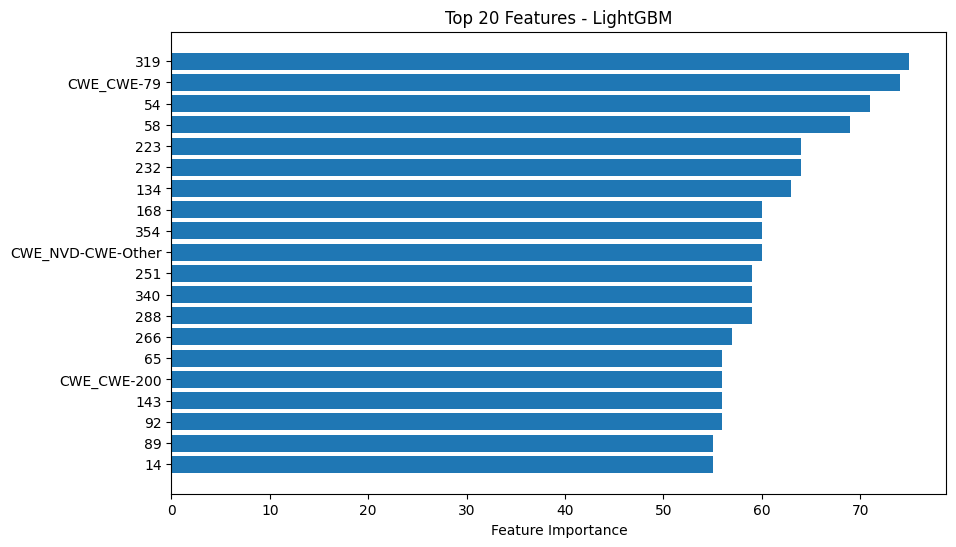

In [55]:
# 1️⃣ Extract preprocessed column names
numeric_cols = pipeline.named_steps['preprocessor'].transformers_[0][2]  # numeric features
categorical_cols = list(
    pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)

feature_names = list(numeric_cols) + list(categorical_cols)

# 2️⃣ Get feature importance
lgbm_model = pipeline.named_steps['classifier'].named_estimators_['lgbm']
importance = lgbm_model.feature_importances_

# 3️⃣ Create DataFrame
feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importance})
feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False)

# 4️⃣ Plot top 20
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(feat_imp_df['feature'][:20][::-1], feat_imp_df['importance'][:20][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Features - LightGBM")
plt.show()


In [53]:
# ======================= UNSEEN SAMPLE TEST =======================
import random

# Randomly select 100 samples from X_test
if len(X_test) >= 100:
    sample_idx = random.sample(range(len(X_test)), 100)
else:
    sample_idx = range(len(X_test))

X_sample = X_test.iloc[sample_idx]
y_sample = y_test.iloc[sample_idx]

# Predict
y_pred_sample = pipeline.predict(X_sample)

# Metrics
sample_acc = accuracy_score(y_sample, y_pred_sample)
sample_f1 = f1_score(y_sample, y_pred_sample, average='macro')
print(f"Accuracy on 100 unseen samples: {sample_acc:.4f}")
print(f"F1 Score on 100 unseen samples: {sample_f1:.4f}")
print("\nClassification Report (100 samples):")
print(classification_report(y_sample, y_pred_sample))


Accuracy on 100 unseen samples: 0.9700
F1 Score on 100 unseen samples: 0.9798

Classification Report (100 samples):
              precision    recall  f1-score   support

        HIGH       0.91      1.00      0.95        31
         LOW       1.00      1.00      1.00        21
      MEDIUM       1.00      0.93      0.97        45
     UNKNOWN       1.00      1.00      1.00         3

    accuracy                           0.97       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.97      0.97      0.97       100



c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


2025-10-19 13:14:57.027 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-19 13:14:57.132 
  command:

    streamlit run C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-10-19 13:14:57.132 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-19 13:14:57.132 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-19 13:14:57.132 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-19 13:14:57.132 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-19 13:14:57.132 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-19 13:14:57.132 Thr

In [57]:
import joblib

# Assuming your pipeline variable is called 'pipeline'
joblib.dump(pipeline, "models/pipeline.pkl")
print("Pipeline saved successfully!")


Pipeline saved successfully!
